# Plots de treino a partir de um arquivo de métricas

Use este notebook para informar o caminho de um `metrics.jsonl` de treino e visualizar os mesmos gráficos definidos em `src/plotting/training_plots.py`.

Importante: o `metadata.json` de um diretório processado descreve o dataset/tokenizador, mas não tem as séries temporais necessárias para loss, perplexidade, learning rate e throughput. Para gerar os plots de treino, o arquivo necessário é o `metrics.jsonl` gerado pelo treinamento.

## Preparação

In [2]:
from __future__ import annotations

import json
import sys
from io import BytesIO
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
from IPython.display import Image, display

if "/home/gabrielstefanello/faculdade/SLM" not in sys.path:
    sys.path.insert(0, "/home/gabrielstefanello/faculdade/SLM")

from src.plotting.training_plots import PLOT_SPECS, _series, load_jsonl_metrics

Path("/home/gabrielstefanello/faculdade/SLM")

PosixPath('/home/gabrielstefanello/faculdade/SLM')

## Configure os arquivos

Altere apenas estas duas variáveis hardcoded.

In [3]:
# Obrigatório para os plots: caminho do metrics.jsonl gerado pelo treino.
# Esse arquivo é JSONL: cada linha é um objeto JSON com métricas como step,
# train_loss, val_loss, validation_perplexity, learning_rate e tokens_per_second.
METRICS_JSONL_PATH = Path("../data/super_bpe_metadata/metrics.jsonl")

# Opcional para resumo: caminho de um .json com metadados.
# Pode ser metadata.json do diretório processado ou training_metadata.json do treino.
# Esse arquivo NÃO gera os plots de treino sozinho.
METADATA_JSON_PATH = Path("../data/super_bpe_metadata/training_metadata.json")

METRICS_JSONL_PATH

PosixPath('../data/super_bpe_metadata/metrics.jsonl')

## Resumos opcionais

In [4]:
def read_json(path: Path) -> dict[str, object]:
    with path.open("r", encoding="utf-8") as handle:
        payload = json.load(handle)
    if not isinstance(payload, dict):
        raise TypeError(f"Esperava um objeto JSON em {path}")
    return payload


def print_json_summary(title: str, path: Path | None, keys: Iterable[str]) -> None:
    if path is None:
        return
    path = Path(path).expanduser().resolve()
    if not path.exists():
        print(f"{title}: arquivo não encontrado: {path}")
        return

    payload = read_json(path)
    print(title)
    print(f"arquivo: {path}")
    for key in keys:
        value = payload.get(key)
        if value is not None:
            print(f"{key}: {value}")
    print()


print_json_summary(
    "Metadados",
    METADATA_JSON_PATH,
    [
        "dataset_name",
        "tokenizer_type",
        "tokenizer_name",
        "vocab_size",
        "train_tokens",
        "validation_tokens",
        "project",
        "parameters",
        "precision",
        "device",
        "world_size",
    ],
)


Metadados
arquivo: /home/gabrielstefanello/faculdade/SLM/data/super_bpe_metadata/training_metadata.json
project: llm_200m_fineweb_edu
parameters: 200647680
precision: bf16
device: cuda:0
world_size: 2



## Plots

/home/gabrielstefanello/faculdade/SLM/data/super_bpe_metadata/metrics.jsonl: 1598 linhas de métricas


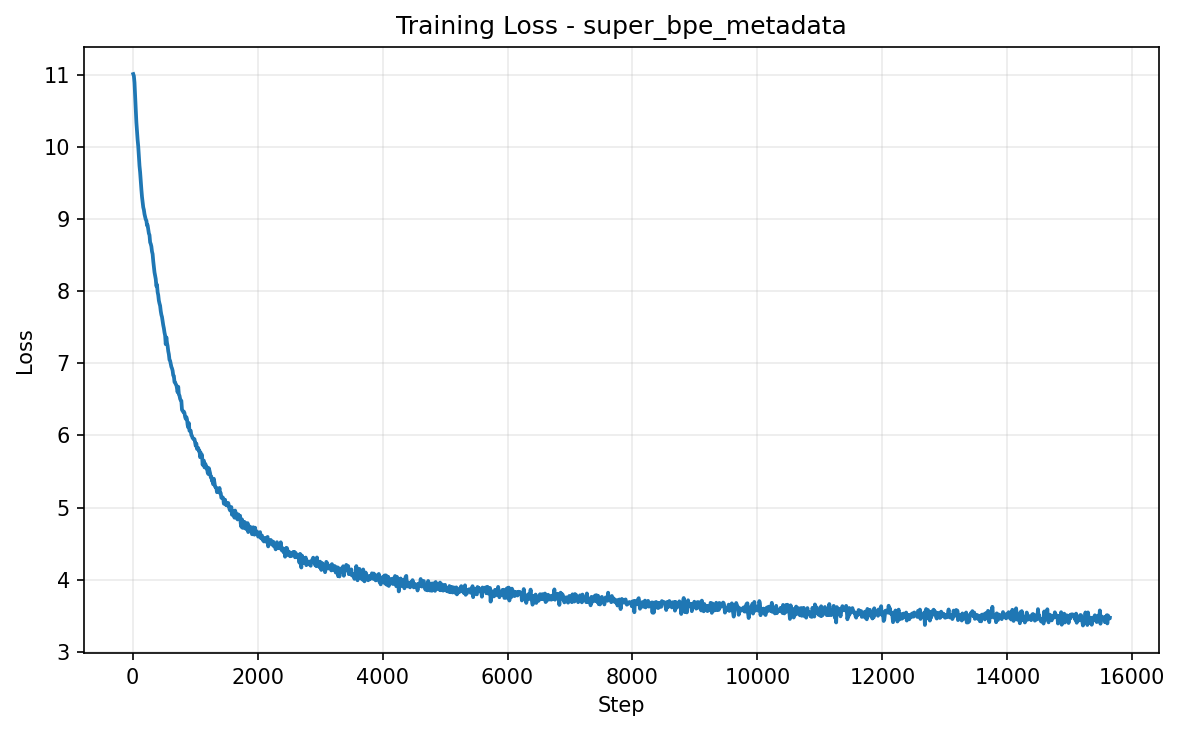

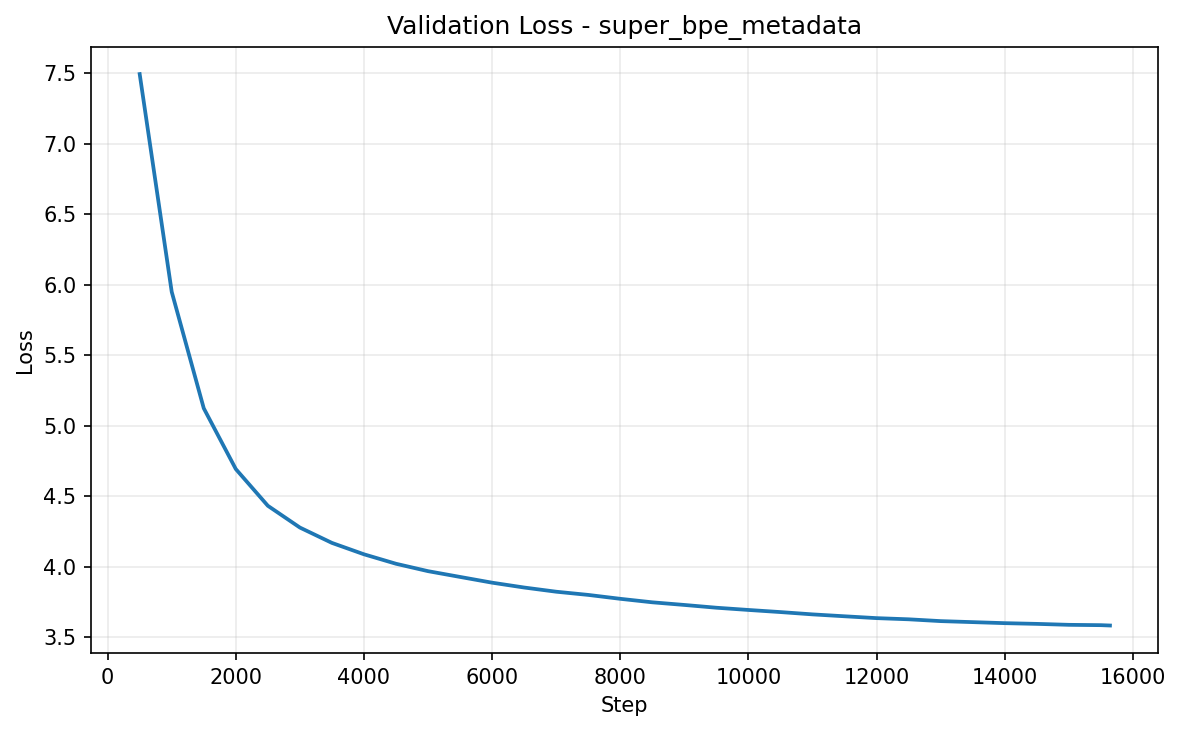

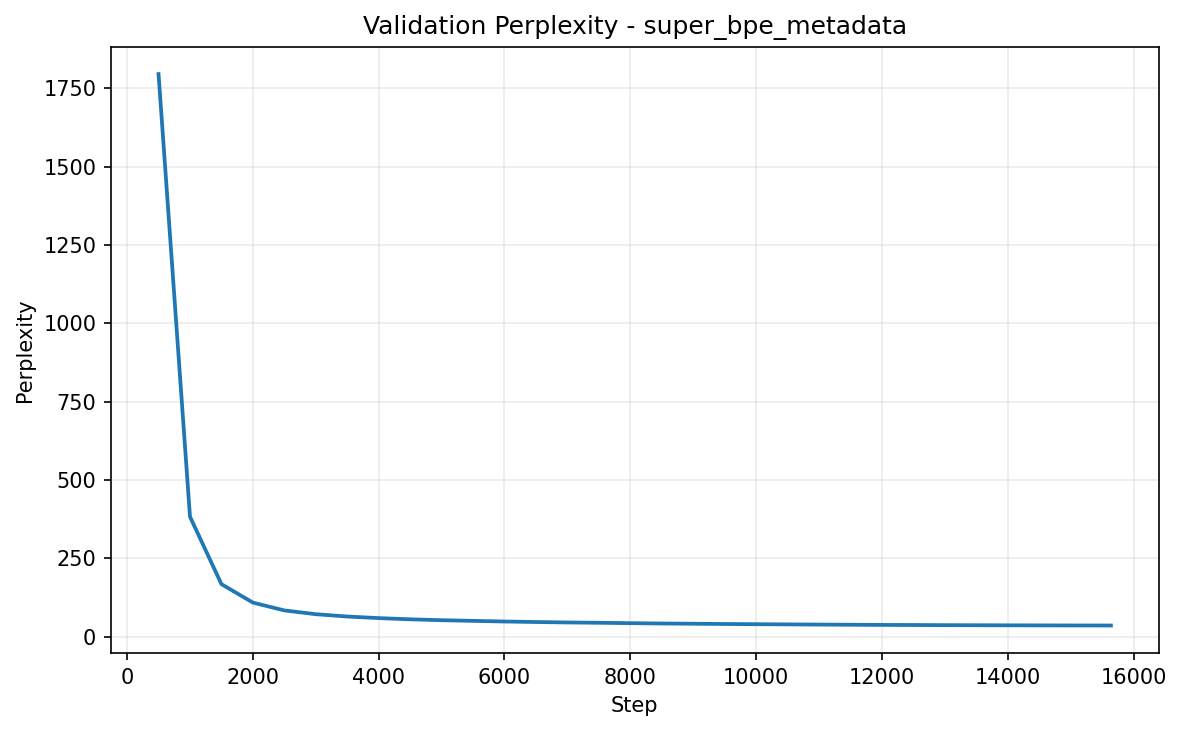

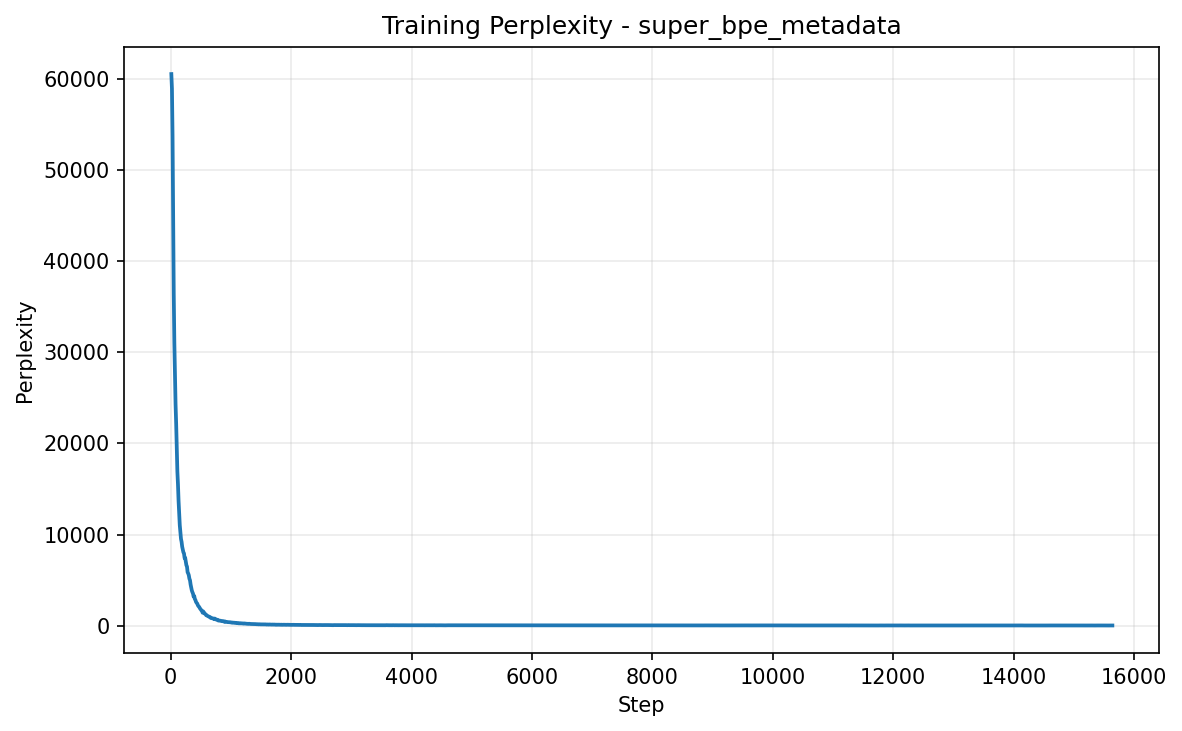

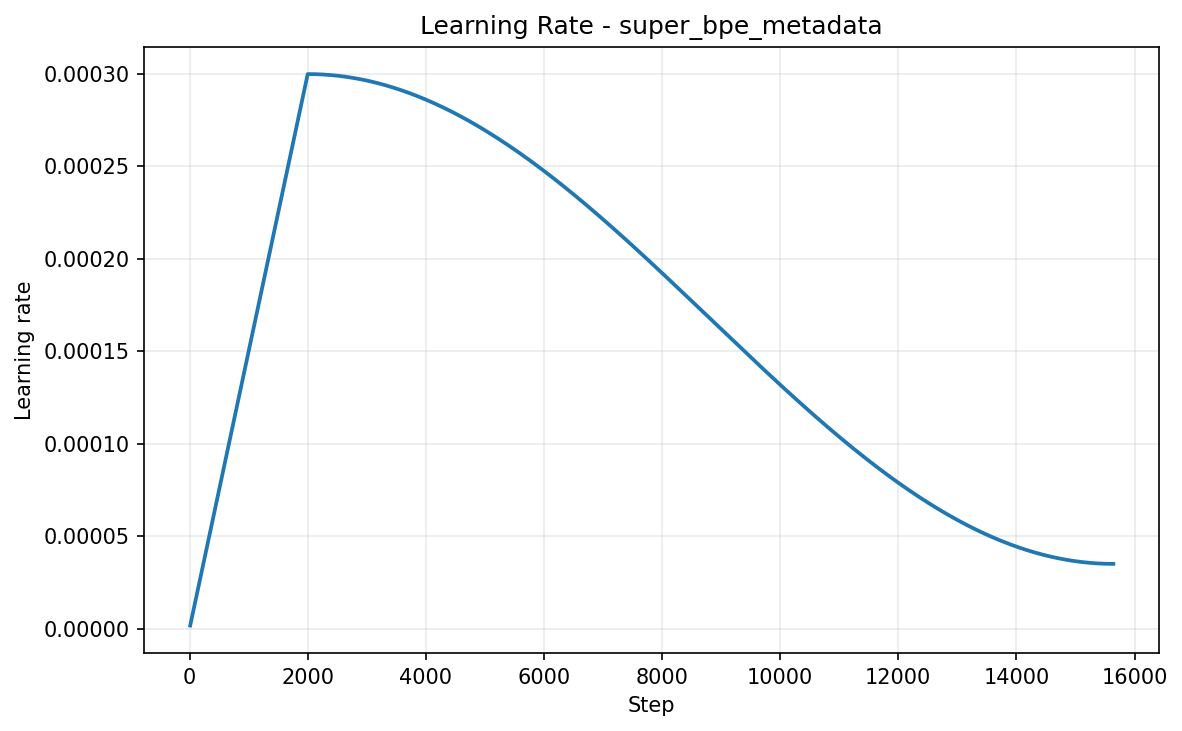

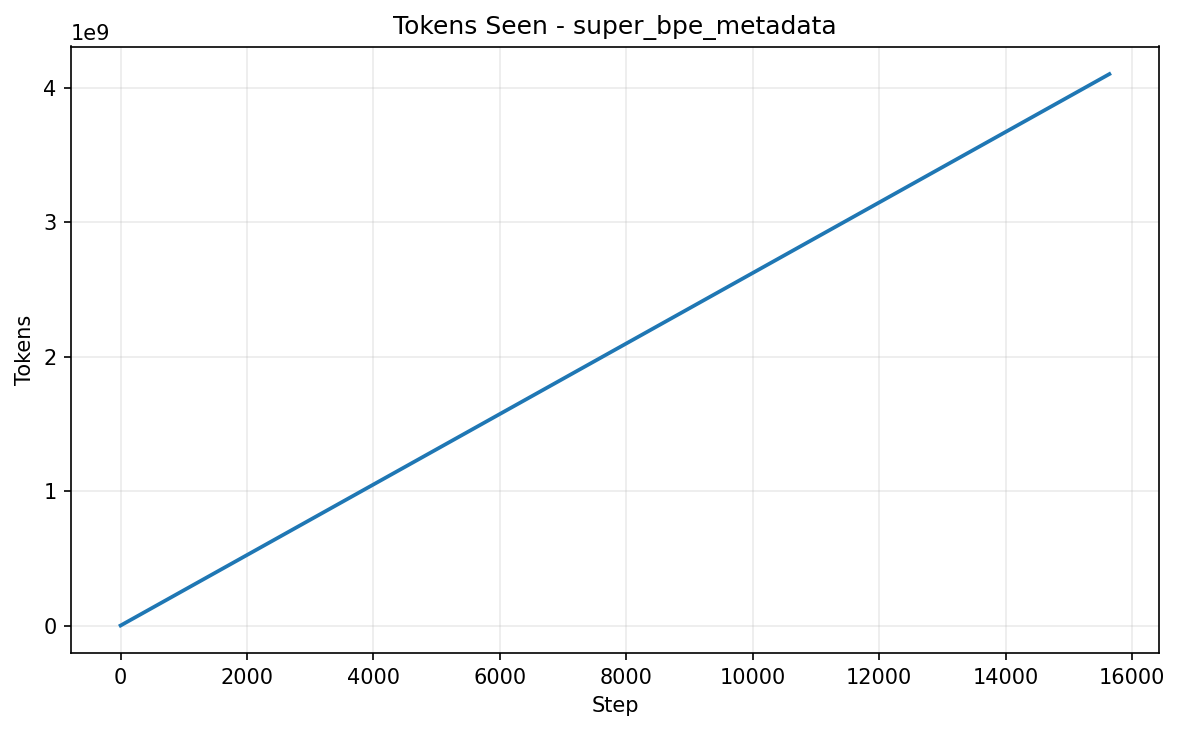

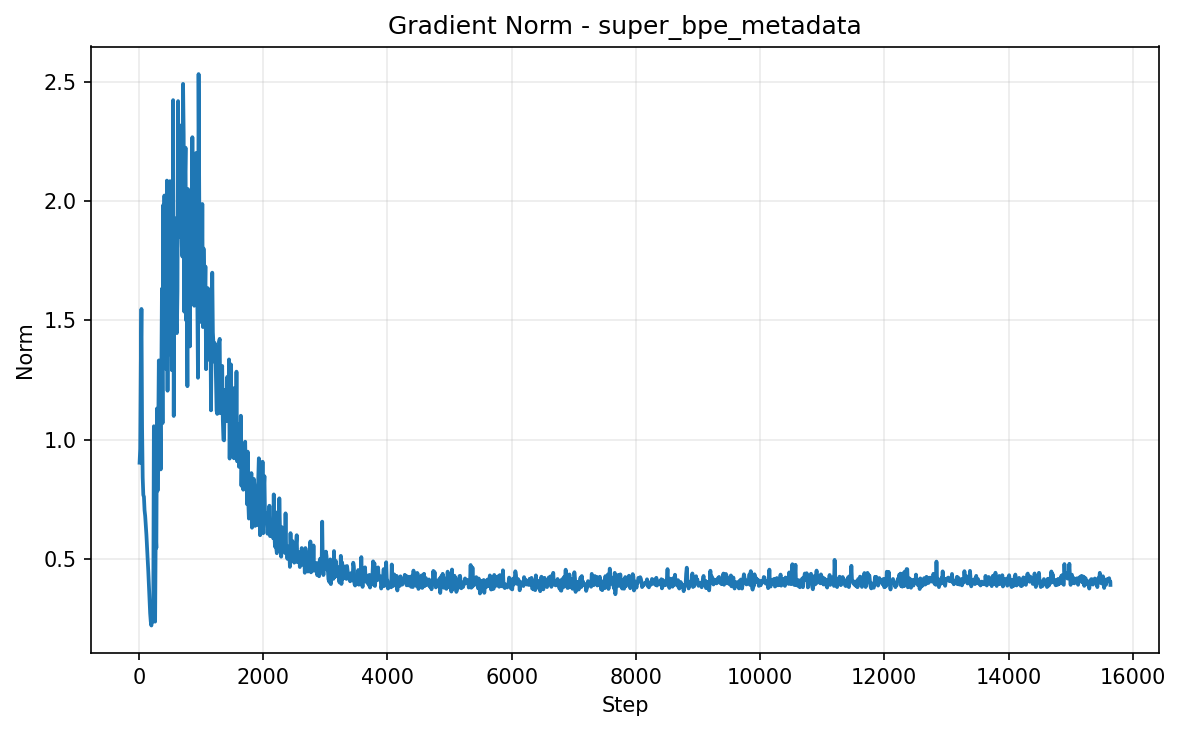

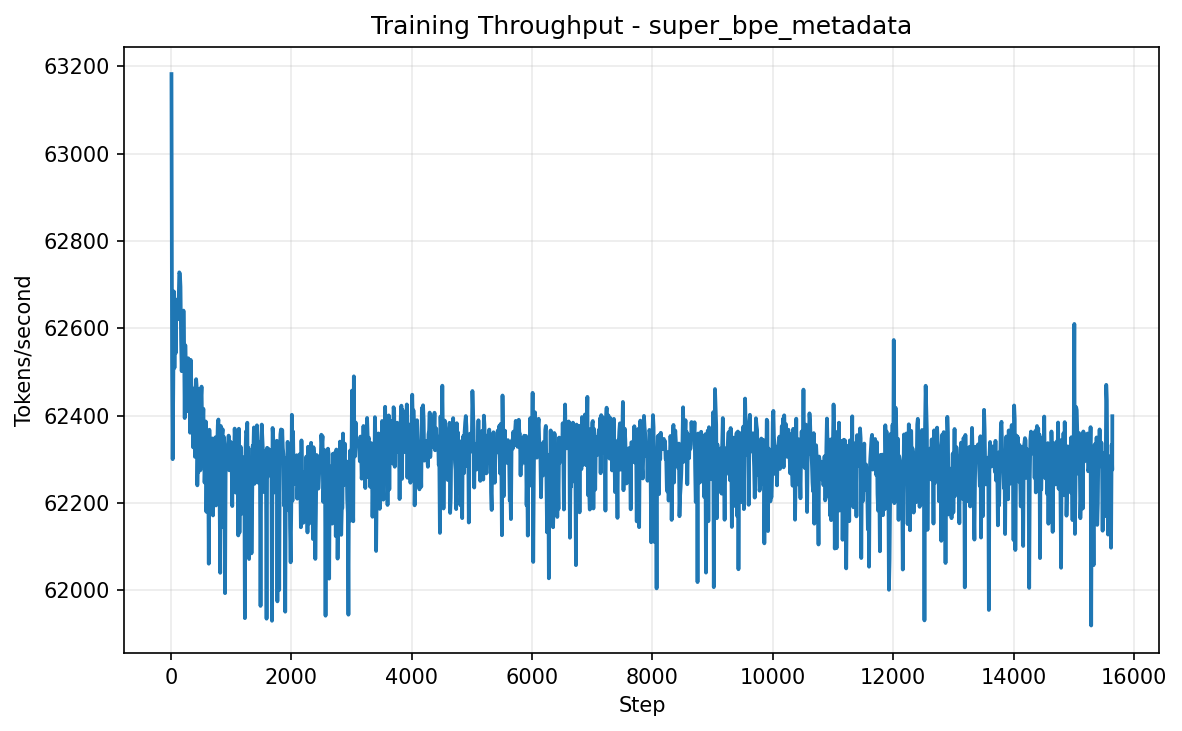

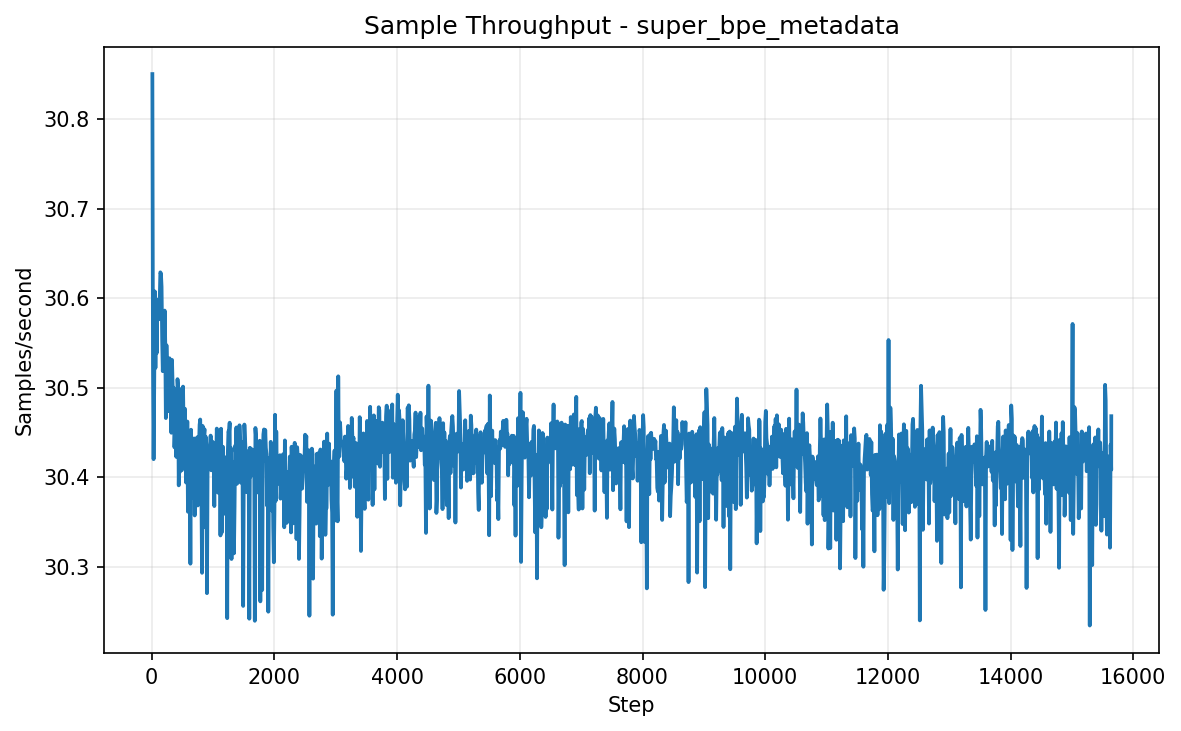

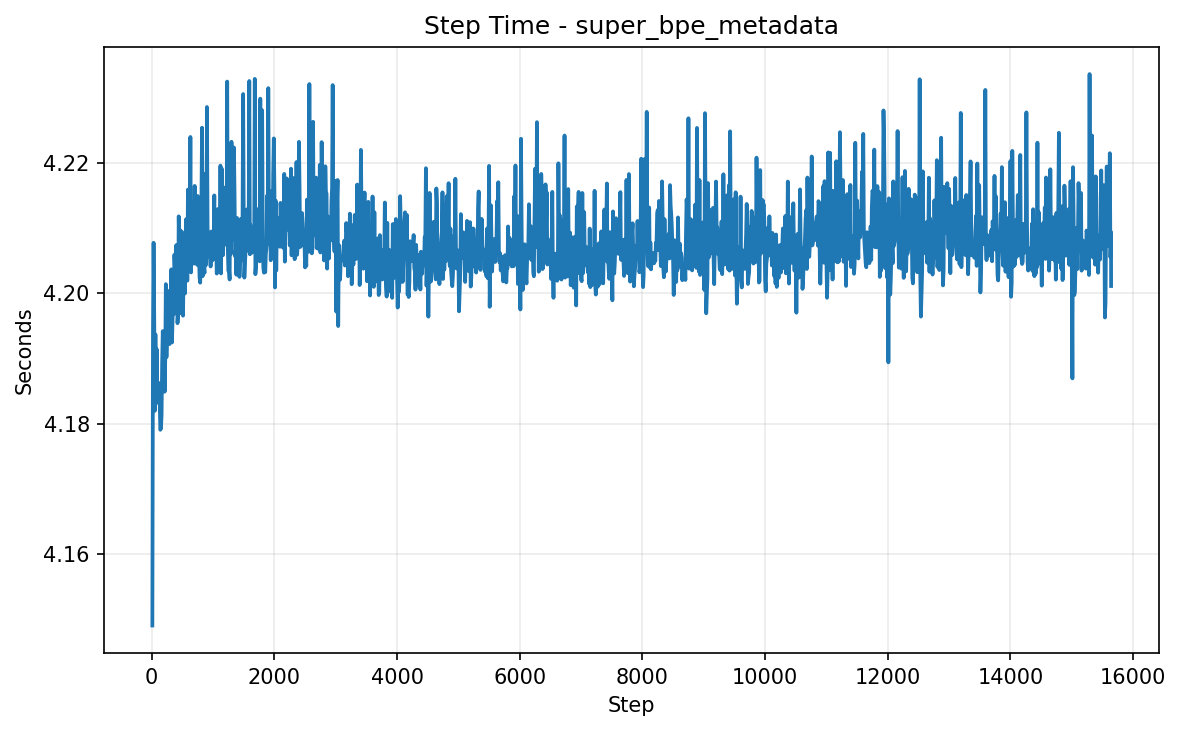

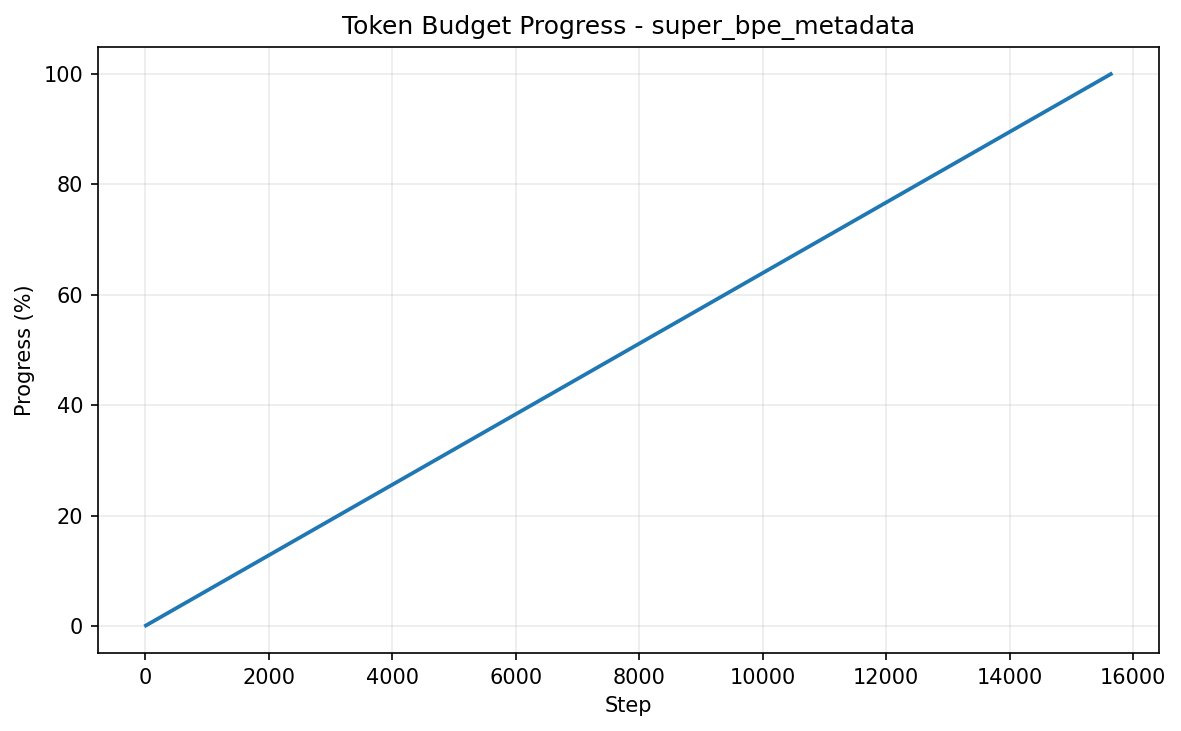

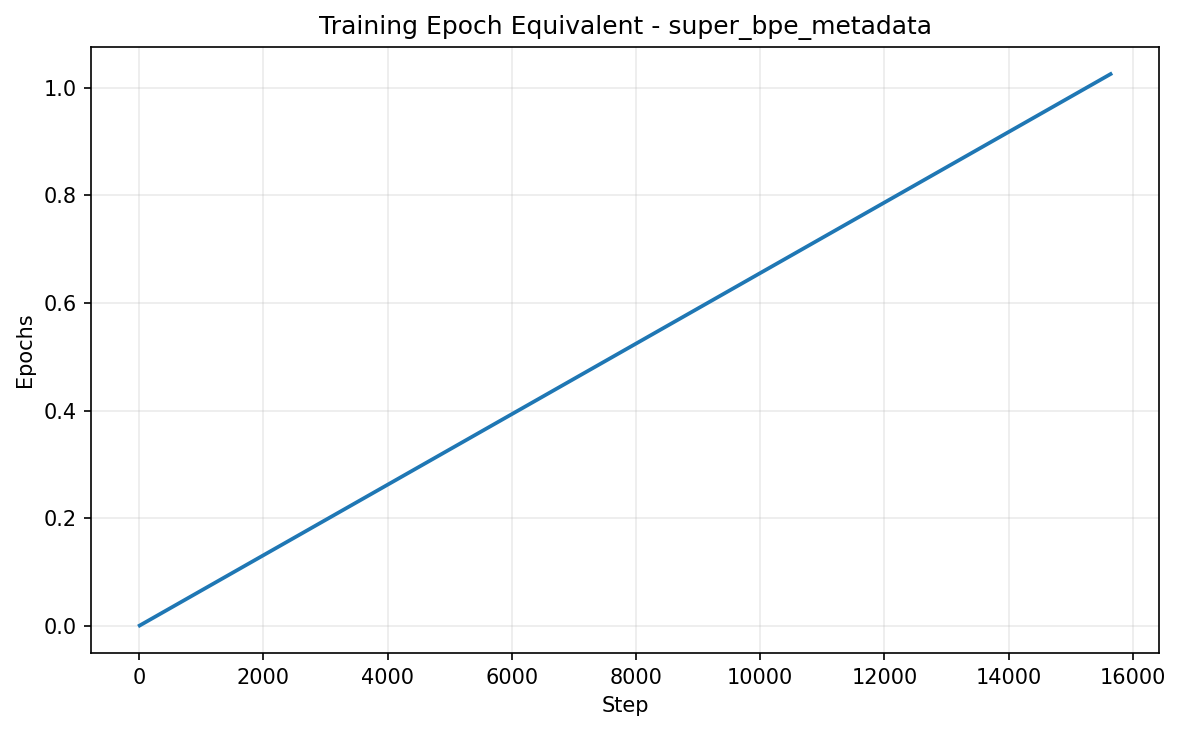

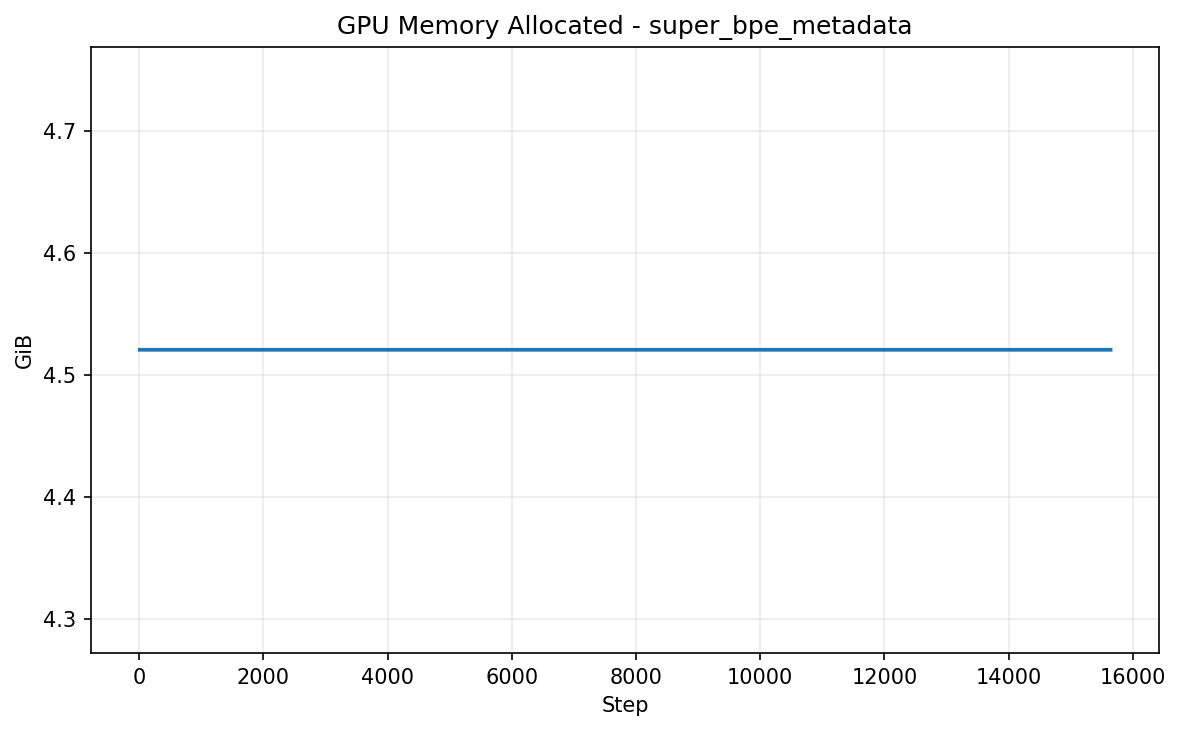

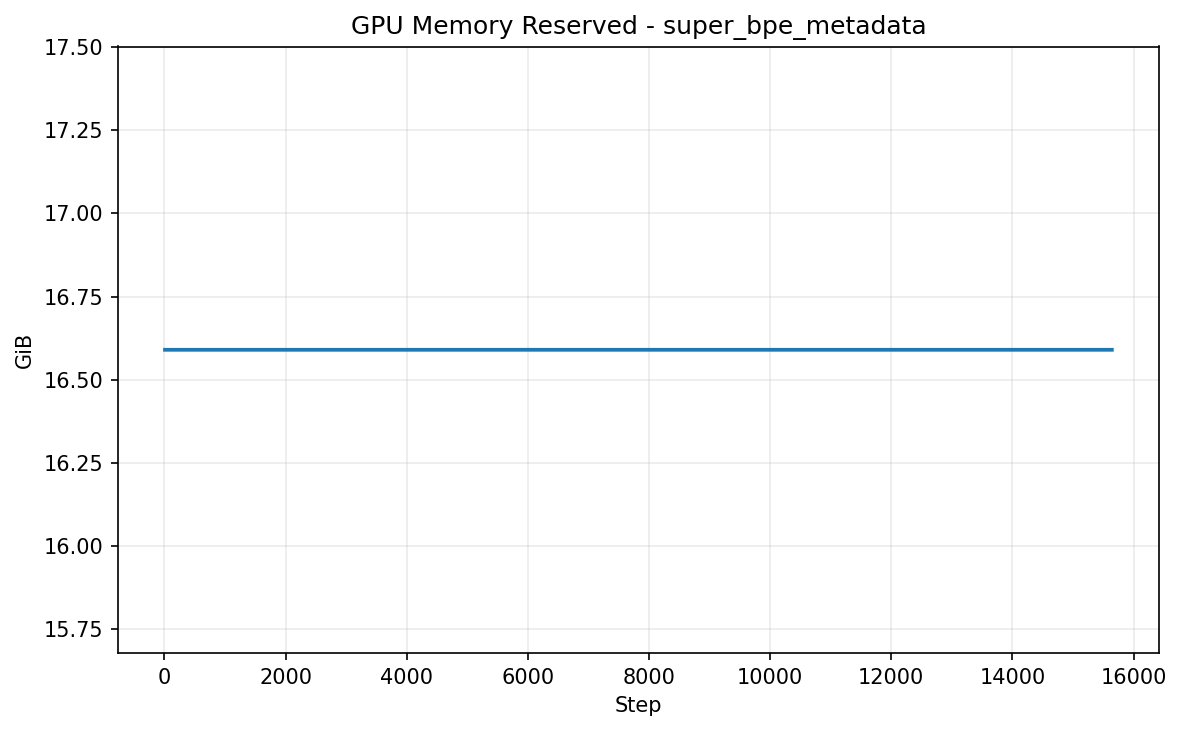

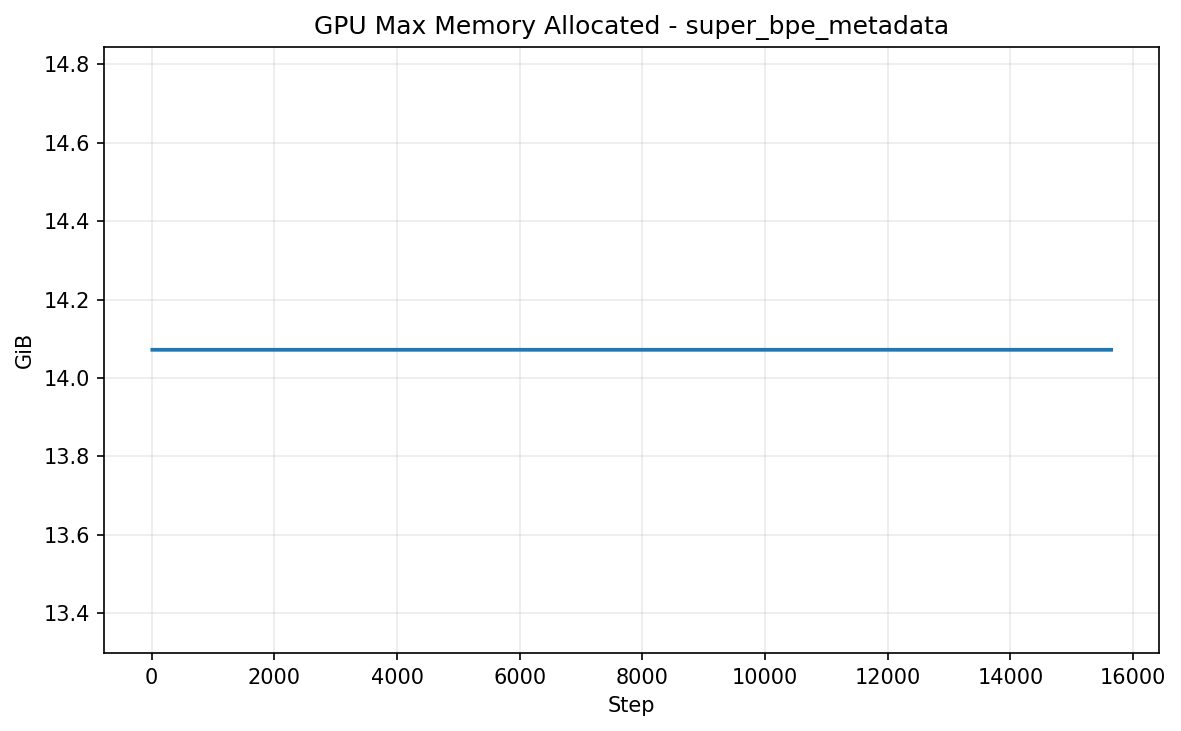

In [5]:
def display_current_figure() -> None:
    buffer = BytesIO()
    plt.savefig(buffer, format="png", dpi=150, bbox_inches="tight")
    plt.close()
    display(Image(data=buffer.getvalue()))


def run_label(metrics_path: Path) -> str:
    return metrics_path.parent.parent.name if metrics_path.parent.name == "logs" else metrics_path.parent.name


def plot_training_metrics(metrics_path: Path, plot_names: Iterable[str] | None = None) -> None:
    metrics_path = Path(metrics_path).expanduser().resolve()
    if not metrics_path.exists():
        raise FileNotFoundError(f"metrics.jsonl não encontrado: {metrics_path}")

    metrics = load_jsonl_metrics(metrics_path)
    names = list(plot_names) if plot_names is not None else list(PLOT_SPECS)
    print(f"{metrics_path}: {len(metrics)} linhas de métricas")

    for name in names:
        spec = PLOT_SPECS.get(name)
        if spec is None:
            print(f"Plot desconhecido: {name}")
            continue

        steps, values = _series(metrics, spec)
        if not values:
            print(f"Sem dados para {name} ({', '.join(spec.keys)})")
            continue

        plt.figure(figsize=(8, 5))
        plt.plot(steps, values, linewidth=1.8)
        plt.xlabel("Step")
        plt.ylabel(spec.ylabel)
        plt.title(f"{spec.title} - {run_label(metrics_path)}")
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        display_current_figure()


plot_training_metrics(METRICS_JSONL_PATH)